# Matrix Capsules with EM Routing — Summary

# https://openreview.net/pdf?id=HJWLfGWRb

## Abstract
This paper introduces a new capsule architecture in which each capsule has a logistic unit representing the probability that an entity is present and a 4×4 matrix representing its pose. Lower-level capsules vote for the pose of higher-level capsules by multiplying their pose matrix with a learned, viewpoint-invariant transformation matrix, and these votes are combined via an iterative routing procedure based on the Expectation-Maximization (EM) algorithm. On smallNORB, the resulting capsule network reduces test errors by 45% relative to the prior state-of-the-art CNN and demonstrates substantially improved robustness to white-box adversarial attacks and better generalization to novel viewpoints.

## Problems
- Convolutional neural networks tie weights across spatial locations to share knowledge, but this mechanism does not capture part-whole viewpoint relationships, which vary in complicated, nonlinear ways at the pixel level.
- Prior capsule work (Sabour et al., 2017) using vector-output capsules with cosine-based agreement has several deficiencies: an unprincipled squashing non-linearity is needed to bound vector length as a presence probability, preventing a well-defined objective function for routing; cosine similarity saturates near 1 and cannot distinguish "good" from "very good" agreement; and vector poses of dimension $$n$$ require $$n^2$$-parameter transformation matrices, which is parameter-inefficient.
- CNNs generalize poorly to viewpoints outside the range seen during training and are highly vulnerable to adversarial perturbations.
- Finding clusters of agreeing high-dimensional votes (for part-whole assignment) is non-trivial because, unlike low-dimensional translation space, high-dimensional pose space cannot be gridded to facilitate convolution-like operations.

## Proposed Solutions
- Represent each capsule's pose as a 4×4 matrix $$M$$ and its presence as a separate logistic activation probability $$a$$, decoupling existence probability from pose representation.
- Compute votes via linear transformation: $$V_{ij} = M_i W_{ij}$$, where $$W_{ij}$$ is a learned, viewpoint-invariant transformation matrix between capsule $$i$$ in layer $$L$$ and capsule $$j$$ in layer $$L+1$$.
- Route votes to higher-level capsules using an iterative EM-based procedure ("EM Routing") that fits a mixture of Gaussians, where each higher-level capsule corresponds to a Gaussian and lower-level votes correspond to (fractionally weighted) data points.
- Derive per-dimension cost using the negative log probability density under a Gaussian model:
$$\text{cost}_j^h = \left(\ln(\sigma_j^h) + \frac{1}{2} + \frac{\ln(2\pi)}{2}\right)\sum_i r_{ij}$$
- Determine each higher-level capsule's activation using a minimum-description-length trade-off between activating versus not activating, passed through a logistic function:
$$a_j = \text{logistic}\left(\lambda\left(\beta_a - \beta_u \sum_i r_{ij} - \sum_h \text{cost}_j^h\right)\right)$$
- Introduce "Coordinate Addition" to preserve fine-grained positional information when convolutional capsule layers connect to the final, non-convolutional class-capsule layer.
- Replace the margin loss with a "spread loss" that directly maximizes the gap between the target class activation and other classes' activations, with a margin linearly increased during training to avoid dead capsules:
$$L_i = (\max(0, m - (a_t - a_i)))^2, \qquad L = \sum_{i \neq t} L_i$$

## Purpose
The goal is to overcome the representational and computational deficiencies of vector-based capsules by using matrix poses and a principled, EM-derived routing procedure, thereby improving shape recognition accuracy, viewpoint generalization, and adversarial robustness while substantially reducing model parameter count.

## Methodology
| Component | Description |
|---|---|
| Architecture | ReLU Conv1 (5×5, 32 channels, stride 2) → PrimaryCaps (4×4 pose + sigmoid activation) → two 3×3 convolutional capsule layers (32 capsule types each, strides 2 and 1) → final class capsule layer (one capsule per class), with shared transformation matrices and Coordinate Addition between the last conv-capsule layer and the class layer |
| Routing | EM Routing, typically 3 iterations, alternating E-step (recomputing assignment probabilities $$R_{ij}$$) and M-step (recomputing capsule means, variances, and activations) |
| Loss | Spread loss (Eq. 3), margin increased linearly from 0.2 to 0.9 during training |
| Baseline | CNN with two convolutional layers (32/64 channels, 5×5 kernel, stride 1, 2×2 max pooling) and a 1024-unit fully connected layer with dropout, extensively hyperparameter-tuned (4.2M parameters) |
| Primary dataset | smallNORB (LeCun et al., 2004): 5 toy classes (airplanes, cars, trucks, humans, animals), 24,300 stereo pairs (96×96, downsampled to 48×48) each for training/test, varying azimuth, elevation, and lighting |
| Additional datasets | NORB (jittered, with background), MNIST, CIFAR-10 |
| Robustness evaluation | FGSM and Basic Iterative Method (BIM) white-box adversarial attacks (untargeted and targeted); black-box attacks using adversarial examples generated by a separate CNN |
| Generalization test | Trained on limited azimuth/elevation ranges, tested on novel (unseen) ranges, with capsule training stopped early to match CNN accuracy on familiar viewpoints for fair comparison |

## Results
- **smallNORB benchmark**: The best capsule model (3 routing iterations, matrix pose, spread loss, Coordinate Addition) achieves 1.8% test error with a single central crop and 1.4% with multi-crop averaging, versus 5.2% for the tuned CNN baseline (4.2M parameters) and the previous best non-metadata result of 2.56% (Cireşan et al., 2011); this constitutes a 45% reduction in test errors relative to state-of-the-art.
- **Parameter efficiency**: The full capsule model uses ~310K parameters (15× fewer than the CNN baseline), and a smaller variant ($$A{=}64, B{=}8, C{=}D{=}16$$) with only 68K parameters still achieves 2.2% test error, beating prior state-of-the-art.
- **Ablations (Table 1)**: 3 routing iterations outperform 1, 2, and 5 iterations; matrix poses outperform vector poses; Coordinate Addition improves results; spread loss outperforms margin loss (Sabour et al., 2017) and cross-entropy loss.
- **NORB and other datasets**: 2.6% error on NORB (jittered, with background), on par with state-of-the-art (2.7%); 0.44% test error on MNIST; 11.9% test error on CIFAR-10 with an enlarged first layer (256 channels).
- **Novel viewpoint generalization**: When capsule and CNN models are matched on familiar-viewpoint accuracy, capsules reduce test error on novel viewpoints by about 30% for both novel azimuths (20% → 13.5%) and novel elevations (17.8% → 12.3%).
- **Adversarial robustness**: Capsules are substantially more robust to FGSM and BIM white-box attacks than the CNN baseline; capsule accuracy under untargeted attack never falls below chance (20%), whereas CNN accuracy drops well below chance at $$\epsilon$$ as small as 0.2. Robustness is not attributable merely to gradient numerical instability (capsule gradients are only ~2 orders of magnitude smaller than CNN gradients, not the ~16 orders reported elsewhere for spurious robustness). However, capsules show no notable advantage over CNNs in black-box attack settings.
- **Routing visualization**: Vote-distance histograms (Fig. 2) show that after the first EM iteration votes are distributed roughly equally across capsules, but by the third iteration they concentrate into tight clusters around the correct class capsule, illustrating the routing procedure's clustering behavior; a rare failure case shows a plane being confused with a car by the third iteration.

## Conclusions
The proposed matrix-capsule architecture with EM routing addresses key theoretical shortcomings of vector-based capsules by decoupling entity presence (a logistic unit) from pose (a matrix), and by grounding the routing procedure in an EM-derived, minimum-description-length objective rather than an unprincipled squashing non-linearity and saturating cosine similarity. Empirically, this yields substantial gains in shape-recognition accuracy on smallNORB with far fewer parameters than a comparable CNN, meaningfully better generalization to novel viewpoints, and markedly improved robustness to white-box adversarial attacks, though not to black-box attacks. The authors position smallNORB as a deliberately controlled but naturalistic testbed for capsule research and identify scaling the approach efficiently to larger datasets such as ImageNet as future work.

# Mathematical and Statistical Content Summary

## 1. Capsule Representation: Pose Matrix and Activation
Each capsule has a 4×4 pose matrix $$M$$ and a scalar activation probability $$a$$.

**Role:** Separates "what the pose is" (a matrix encoding viewpoint-dependent geometric properties) from "whether the entity exists" (a single logistic probability), avoiding the need to overload vector length with existence information as in prior capsule work.

## 2. Vote Computation
$$V_{ij} = M_i W_{ij}$$

- $$M_i$$: pose matrix of capsule $$i$$ in the lower layer.
- $$W_{ij}$$: learned, viewpoint-invariant transformation matrix between capsule $$i$$ and capsule $$j$$ in the layer above.
- $$V_{ij}$$: the "vote" capsule $$i$$ casts for the pose of capsule $$j$$.

**Role:** Implements the linear relationship between part and whole poses. Since real viewpoint changes affect pose matrices approximately linearly, votes from different correctly-assigned parts should agree (cluster tightly) regardless of viewpoint, forming the basis for routing-by-agreement.

## 3. Gaussian Model of Votes (Per-Dimension)
$$P^h_{i|j} = \frac{1}{\sqrt{2\pi(\sigma_j^h)^2}}\exp\left(-\frac{(V_{ij}^h - \mu_j^h)^2}{2(\sigma_j^h)^2}\right)$$
$$\ln(P^h_{i|j}) = -\frac{(V_{ij}^h - \mu_j^h)^2}{2(\sigma_j^h)^2} - \ln(\sigma_j^h) - \frac{\ln(2\pi)}{2}$$

- $$\mu_j^h$$, $$(\sigma_j^h)^2$$: mean and variance of higher-level capsule $$j$$'s Gaussian model along dimension $$h$$ (i.e., its fitted pose and spread).

**Role:** Treats each higher-level capsule as a Gaussian cluster center in vote space; the log-probability density measures how well a given vote fits that cluster, forming the "energy" used throughout the routing procedure (an application of Gaussian mixture modeling).

## 4. Per-Dimension and Total Cost of Assigning Votes
$$\text{cost}_j^h = \sum_i -r_{ij}\ln(P^h_{i|j}) = \left(\ln(\sigma_j^h) + \frac{1}{2} + \frac{\ln(2\pi)}{2}\right)\sum_i r_{ij}$$

- $$r_{ij}$$: assignment probability (soft responsibility) of lower-level capsule $$i$$ to higher-level capsule $$j$$.

**Role:** Quantifies the description length (coding cost) required to explain all votes assigned to capsule $$j$$ along dimension $$h$$, using a minimum-description-length (MDL) framework. Lower cost means tighter, more confident agreement among votes.

## 5. Capsule Activation Function
$$a_j = \text{logistic}\left(\lambda\left(\beta_a - \beta_u\sum_i r_{ij} - \sum_h \text{cost}_j^h\right)\right)$$

- $$\beta_a$$: fixed cost of activating capsule $$j$$ (coding its mean, variance, and the fact it's active).
- $$\beta_u$$: fixed cost per data point if capsule $$j$$ is not activated (uniform-prior coding cost).
- $$\lambda$$: inverse-temperature hyperparameter, following a schedule that sharpens the decision over iterations.

**Role:** Implements an MDL-based decision: activate a higher-level capsule only if the cost of explaining assigned votes via its Gaussian is cheaper than the fixed cost of leaving them unexplained. The logistic function is shown (via free-energy minimization, Appendix A) to be the theoretically correct function for converting this cost difference into an activation probability.

## 6. EM Routing Algorithm (M-step and E-step)
**M-step** (for each higher-level capsule $$j$$):
$$R_{ij} \leftarrow R_{ij} \cdot a_i$$
$$\mu_j^h \leftarrow \frac{\sum_i R_{ij} V_{ij}^h}{\sum_i R_{ij}}$$
$$(\sigma_j^h)^2 \leftarrow \frac{\sum_i R_{ij}(V_{ij}^h - \mu_j^h)^2}{\sum_i R_{ij}}$$
$$\text{cost}^h = (\beta_u + \log \sigma_j^h)\sum_i R_{ij}, \qquad a_j \leftarrow \text{logistic}\left(\lambda\left(\beta_a - \sum_h \text{cost}^h\right)\right)$$

**E-step** (for each lower-level capsule $$i$$):
$$p_j = \frac{1}{\sqrt{\prod_h 2\pi(\sigma_j^h)^2}}\exp\left(-\sum_h \frac{(V_{ij}^h - \mu_j^h)^2}{2(\sigma_j^h)^2}\right)$$
$$R_{ij} \leftarrow \frac{a_j p_j}{\sum_{k} a_k p_k}$$

**Role:** This is the paper's central algorithm. It alternates between (a) refitting each higher-level Gaussian's mean, variance, and activation given current soft assignments (M-step) and (b) recomputing soft assignments given the current Gaussians and lower-level activations (E-step), iterated a fixed number of times (typically 3). This iteratively concentrates votes into tight, agreeing clusters — implementing "routing-by-agreement" as approximate EM clustering rather than the ad hoc cosine-similarity routing used in prior vector-capsule work.

## 7. Spread Loss (Equation 3)
$$L_i = \left(\max(0, m - (a_t - a_i))\right)^2, \qquad L = \sum_{i \neq t} L_i$$

- $$a_t$$: activation of the target (correct) class capsule.
- $$a_i$$: activation of an incorrect class capsule.
- $$m$$: margin, linearly increased from 0.2 to 0.9 during training.

**Role:** A margin-based, per-class squared-hinge loss (equivalent to squared Hinge loss with $$m=1$$) that directly penalizes any incorrect class whose activation is too close to the correct class's activation. Starting with a small margin and increasing it gradually prevents capsules from being prematurely deactivated ("dead capsules") early in training. The paper notes this is a variant of a multi-class SVM loss studied by Guermeur & Monfrini (2011).

## 8. Free Energy Framework (Appendix A)
Total objective minimized by EM routing (Equation 4):
$$\sum_{j} \Big[a_j(-\beta_a) + a_j\ln(a_j) + (1-a_j)\ln(1-a_j) + \sum_h \text{cost}_j^h + \beta_u\sum_i r_{ij}\Big] + \sum_i a_i r_{ij}\ln(r_{ij})$$

- Combines: (i) MDL cost of activating capsules, (ii) negative entropy of activation probabilities, (iii) expected energy from the M-step (Gaussian fit cost), and (iv) negative entropy of the routing assignment distribution.

**Role:** Provides the theoretical justification connecting EM routing to free-energy minimization (expected energy minus entropy), the same quantity minimized by standard EM for fitting Gaussian mixtures. This formalizes why alternating the E-step (softmax-based reassignment) and M-step (Gaussian refitting) converges to a consistent optimum, unlike the heuristic iterative procedure in prior vector-capsule routing.

## 9. Adversarial Attack Formulation
**FGSM (Fast Gradient Sign Method):**
Perturbs each pixel by a fixed magnitude $$\epsilon$$ in the direction of the sign of the gradient of the loss with respect to pixel intensity.

**BIM (Basic Iterative Method):**
Applies the FGSM perturbation iteratively in smaller steps rather than a single large step.

**Role:** Standard adversarial robustness evaluation methods (not novel to this paper) used to empirically compare the capsule model's and CNN baseline's sensitivity to small, adversarially chosen input perturbations, under both untargeted (reduce accuracy) and targeted (maximize probability of a specific wrong class) attack settings.

## 10. Statistical/Evaluation Methods
- **Test error rate (%)**: primary metric across all experiments (smallNORB, NORB, MNIST, CIFAR-10).
- **Ablation table (Table 1)**: systematic variation of routing iterations, pose type (matrix vs. vector), loss function (spread/margin/cross-entropy), and Coordinate Addition, each evaluated by resulting test error — a controlled comparison method for isolating each architectural component's contribution.
- **Matched-performance comparison (Table 2)**: capsule training is deliberately stopped early so its accuracy on familiar viewpoints matches the CNN baseline, isolating the "generalization to novel viewpoints" effect from a general accuracy advantage — a comparison-of-groups technique controlling for a confounding variable.
- **Gradient sparsity check**: percentage of zero-valued gradients with respect to input pixels is compared between capsule and CNN models, used as a diagnostic to rule out that adversarial robustness is a numerical artifact (per Brendel & Bethge, 2017) rather than a genuine property of the model.
- **Vote-distance histograms (Fig. 2, Appendix Fig. B.2)**: empirical distributions of the distances between votes and their assigned capsule mean at each routing iteration, used descriptively (not as formal hypothesis tests) to illustrate the clustering behavior of EM routing over iterations.

## Summary of Mathematical Contribution
The core mathematical contribution is recasting capsule routing as approximate Expectation-Maximization for fitting a mixture of (transforming) Gaussians: votes from lower-level capsules are treated as data points, higher-level capsules as Gaussian clusters, and routing coefficients as soft cluster assignments. This replaces the earlier vector-capsule routing (based on a squashing non-linearity and cosine similarity) with a principled probabilistic framework, complete with an MDL-derived activation rule (logistic function) and a free-energy justification (Appendix A) for why alternating E- and M-steps converges. The spread loss (Eq. 3) is the paper's other notable mathematical device, providing a more stable, margin-based classification objective. Other quantitative content (error rates, ablations, matched comparisons, gradient sparsity) reflects standard empirical ML evaluation methodology rather than novel statistical theory.

# Research Gaps and Proposed Solutions

| # | Key Problem / Research Gap | Limitation of Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | Vector-based capsules (Sabour et al., 2017) use the length of the pose vector to represent existence probability. | This requires an unprincipled "squashing" non-linearity to bound vector length below 1, which prevents the routing procedure from being derived from a well-defined, sensible objective function. | Decouple existence from pose entirely: represent presence with a separate logistic activation unit and pose with a 4×4 matrix, removing the need for length-based squashing. |
| 2 | Vector capsules measure agreement between predictions using cosine similarity between pose vectors. | Cosine similarity saturates near 1, making it insensitive to the difference between good and very good agreement, which limits the precision of the routing signal. | Measure agreement via the negative log variance of a Gaussian cluster fitted to the votes (an EM-based approach), which does not saturate and provides a continuous, statistically grounded measure of agreement. |
| 3 | Vector-based capsule poses of dimension $$n$$ require transformation matrices with $$n^2$$ parameters. | This is parameter-inefficient, contributing to larger models than necessary for a given representational capacity. | Represent pose as a 4×4 matrix and use matrix multiplication for transformations, achieving comparable or better accuracy with substantially fewer parameters (e.g., 310K vs. 4.2M in the CNN baseline). |
| 4 | Assigning parts to wholes in high-dimensional pose space cannot exploit the same gridding trick used for convolution in low-dimensional translation space. | Standard CNNs and prior capsule routing lack a principled way to find tight clusters of agreeing high-dimensional votes amid irrelevant votes, limiting effective part-whole segmentation. | Introduce EM Routing, an iterative procedure that treats higher-level capsules as Gaussians and lower-level votes as (fractionally weighted) data points, using EM to find clusters of agreeing votes. |
| 5 | Deciding whether to activate a higher-level capsule lacked a principled criterion in earlier capsule formulations. | Without a theoretically motivated activation rule, capsule activation could not be tied to a coherent probabilistic or information-theoretic objective. | Derive an activation function from the minimum description length (MDL) principle, comparing the coding cost of activating vs. not activating a capsule, passed through a logistic function (Eq. 2). |
| 6 | Connecting convolutional capsule layers to a final, non-convolutional class-capsule layer risks discarding precise location information carried by convolutional capsules. | Losing fine positional information at this transition could degrade the network's ability to represent exact pose, weakening downstream classification and segmentation. | Introduce "Coordinate Addition," which adds the scaled receptive-field coordinates of each capsule into its vote matrix, encouraging shared transformations to encode fine positional information. |
| 7 | The margin loss used in prior capsule work is sensitive to model initialization and hyperparameters. | Training instability from this sensitivity ("dead capsules" occurring early in training) can hinder reliable optimization. | Use "spread loss" (Eq. 3), which directly maximizes the gap between the target class's activation and other classes', with a margin linearly increased from 0.2 to 0.9 during training to avoid dead capsules. |
| 8 | CNNs generalize poorly to viewpoints not seen during training, since translational weight-sharing does not extend to other affine transformations. | Prior architectures require either exponentially many replicated feature detectors or exponentially larger training sets to handle novel viewpoints, and comparisons of viewpoint generalization are often confounded by overall accuracy differences. | Use capsules' matrix pose and vote-agreement mechanism, which encodes viewpoint-invariant part-whole relationships; evaluate this specifically via a matched-accuracy comparison (Table 2) isolating novel-viewpoint generalization from general accuracy gains. |
| 9 | Neural networks, including CNNs, are highly vulnerable to adversarial perturbations (e.g., FGSM, BIM attacks). | Standard CNN classifiers can have their accuracy dramatically reduced by small, imperceptible input perturbations, raising reliability and security concerns. | Demonstrate empirically that the capsule model with EM routing is substantially more robust to white-box FGSM and BIM attacks than a comparable CNN, and verify this robustness is not merely due to gradient numerical instability. |
| 10 | It was unclear whether a shape-recognition-focused capsule system (developed on smallNORB) could scale or generalize beyond a narrow benchmark. | Earlier capsule work primarily targeted MNIST/MultiMNIST, leaving open questions about performance on more natural-image-like, context-free shape recognition tasks. | Evaluate the architecture on smallNORB — a benchmark designed to isolate shape recognition from color/context confounds while being closer to natural images than MNIST — and additionally test on NORB, MNIST, and CIFAR-10 to assess broader applicability. |

In [12]:
# ============================================================
# EDUCATIONAL REPLICATION: "Matrix Capsules with EM Routing"
# (Hinton, Sabour & Frosst, ICLR 2018)
# Simplified implementation applied to CIFAR-10 image classification.
#
# Core ideas preserved:
#   - Capsules with a 4x4 POSE MATRIX + separate logistic ACTIVATION.
#   - Votes computed via learned transformation matrices (pose * W).
#   - EM ROUTING (iterative E-step/M-step) to cluster agreeing votes.
#   - SPREAD LOSS for classification (margin increased during training).
#
# NOTE: This code is NOT executed here. Copy into Google Colab / Jupyter.
# ============================================================

# ---------------------------------------------------------------
# 0. IMPORTS
# ---------------------------------------------------------------
import io
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T

from datasets import load_dataset  # HuggingFace datasets (mandatory source)

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.metrics import confusion_matrix

from IPython.display import display, Image as IPImage

In [13]:
# ---------------------------------------------------------------
# GLOBAL WHITE-THEME SETTINGS (applied globally + reinforced per-axis later)
# ---------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "grid.color": "#d9d9d9",
    "legend.labelcolor": "black",
    "font.size": 10,
})

In [14]:
# ---------------------------------------------------------------
# REPRODUCIBILITY
# ---------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
# ---------------------------------------------------------------
# 1. CLASS NAMES (CIFAR-10, exact order, labels 0-9)
# ---------------------------------------------------------------
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
NUM_CLASSES = len(CLASS_NAMES)

In [16]:
# ---------------------------------------------------------------
# 2. DATASET PREPARATION (HuggingFace CIFAR-10 — mandatory source)
# ---------------------------------------------------------------
ds = load_dataset("uoft-cs/cifar10")

train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset.
    Reads the 'img' field as a PIL image, converts to RGB, applies the
    given torchvision transform, and returns (image_tensor, label).
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        img = sample["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = int(sample["label"])
        return img_tensor, label


train_full = HFCifar10Dataset(ds["train"], train_transform)
test_full = HFCifar10Dataset(ds["test"], test_transform)

# Small subsets for a fast, educational 5-epoch run
train_subset = Subset(train_full, list(range(2000)))
test_subset = Subset(test_full, list(range(400)))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False, num_workers=2)

In [17]:
# ---------------------------------------------------------------
# SANITY CHECK
# ---------------------------------------------------------------
sanity_images, sanity_labels = next(iter(train_loader))
print("Number of training samples:", len(train_subset))
print("Number of test samples:", len(test_subset))
print("Shape of one batch of images:", sanity_images.shape)
print("Label range: [{}, {}]".format(sanity_labels.min().item(), sanity_labels.max().item()))
print("First 8 class names in batch:", [CLASS_NAMES[l] for l in sanity_labels[:8].tolist()])

Number of training samples: 2000
Number of test samples: 400
Shape of one batch of images: torch.Size([64, 3, 64, 64])
Label range: [0, 9]
First 8 class names in batch: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [24]:
# ---------------------------------------------------------------
# 3. MODEL DEFINITION — Simplified Matrix Capsules with EM Routing
# ---------------------------------------------------------------
#
# Simplified architecture (adapted for speed / education, not exact scale
# of the paper, but preserving the core mechanisms):
#
#   Conv1        : ReLU conv layer -> local feature detectors
#   PrimaryCaps  : produces a POSE MATRIX (4x4=16 values) + ACTIVATION
#                  (logistic) per capsule type, per spatial location
#   ClassCaps    : one capsule per class, populated via EM ROUTING between
#                  PrimaryCaps and ClassCaps (fully-connected routing,
#                  simplified from the paper's convolutional capsule
#                  layers for educational clarity)
#   Loss         : Spread Loss (Eq. 3 in the paper), margin increased
#                  linearly over training epochs.

POSE_DIM = 4                 # 4x4 pose matrix -> 16 values
POSE_SIZE = POSE_DIM * POSE_DIM
NUM_PRIMARY_TYPES = 8         # number of primary capsule types (channels)
NUM_ROUTING_ITERS = 3          # paper recommends 3 EM routing iterations


class PrimaryCapsuleMatrix(nn.Module):
    """
    Produces, for each of NUM_PRIMARY_TYPES capsule types at each spatial
    location: a 4x4 pose matrix (flattened to 16 values) and a scalar
    logistic activation probability.
    """
    def __init__(self, in_channels, num_types, pose_size, kernel_size=9, stride=2):
        super().__init__()
        self.num_types = num_types
        self.pose_size = pose_size
        # One conv producing pose values, another producing activation logits
        self.pose_conv = nn.Conv2d(in_channels, num_types * pose_size,
                                    kernel_size=kernel_size, stride=stride)
        self.act_conv = nn.Conv2d(in_channels, num_types,
                                   kernel_size=kernel_size, stride=stride)

    def forward(self, x):
        pose = self.pose_conv(x)                      # (b, types*pose_size, H, W)
        act_logits = self.act_conv(x)                  # (b, types, H, W)

        b, _, h, w = pose.shape
        pose = pose.view(b, self.num_types, self.pose_size, h, w)
        pose = pose.permute(0, 1, 3, 4, 2).contiguous()  # (b, types, h, w, pose_size)
        pose = pose.view(b, self.num_types * h * w, self.pose_size)  # (b, N, pose_size)

        act = torch.sigmoid(act_logits)                 # activation in [0,1]
        act = act.view(b, self.num_types, h, w)
        act = act.view(b, self.num_types * h * w)        # (b, N)

        return pose, act


class EMRoutingClassCaps(nn.Module):
    def __init__(self, num_in_caps, pose_size, num_out_caps, num_iters=NUM_ROUTING_ITERS):
        super().__init__()
        self.num_in_caps = num_in_caps
        self.num_out_caps = num_out_caps
        self.pose_size = pose_size
        self.num_iters = num_iters

        self.W = nn.Parameter(0.01 * torch.randn(1, num_in_caps, num_out_caps,
                                                  pose_size, pose_size))

        # FIX: beta_u shape (1, num_out_caps) — no extra middle dim, no transpose needed
        self.beta_u = nn.Parameter(torch.zeros(1, num_out_caps))
        self.beta_a = nn.Parameter(torch.zeros(1, num_out_caps))

    def forward(self, pose_in, act_in, lam=1.0):
        batch_size = pose_in.shape[0]

        W = self.W.expand(batch_size, -1, -1, -1, -1)
        V = torch.einsum('bip,bijpq->bijq', pose_in, W)

        R = torch.full((batch_size, self.num_in_caps, self.num_out_caps),
                        1.0 / self.num_out_caps, device=pose_in.device)

        mu = None
        act_out = None

        for it in range(self.num_iters):
            # ===== M-STEP =====
            R_weighted = R * act_in.unsqueeze(-1)
            R_sum = R_weighted.sum(dim=1, keepdim=True) + 1e-8   # (b, 1, N_out)

            mu = (R_weighted.unsqueeze(-1) * V).sum(dim=1) / R_sum.transpose(1, 2)

            diff_sq = (V - mu.unsqueeze(1)) ** 2
            var = (R_weighted.unsqueeze(-1) * diff_sq).sum(dim=1) / R_sum.transpose(1, 2)
            var = var.mean(dim=-1, keepdim=True) + 1e-6
            sigma = torch.sqrt(var)

            # FIX: beta_u is (1, N_out); sigma.squeeze(-1) and R_sum.squeeze(1) are (b, N_out)
            cost = (self.beta_u + torch.log(sigma.squeeze(-1) + 1e-8)) * R_sum.squeeze(1)  # (b, N_out)
            act_out = torch.sigmoid(lam * (self.beta_a - cost))

            if it < self.num_iters - 1:
                # ===== E-STEP =====
                var_exp = var.unsqueeze(1)
                mu_exp = mu.unsqueeze(1)
                sq_dist = ((V - mu_exp) ** 2).sum(dim=-1, keepdim=False)
                log_p = -0.5 * sq_dist / var_exp.squeeze(-1) \
                        - 0.5 * self.pose_size * torch.log(2 * np.pi * var_exp.squeeze(-1) + 1e-8)
                logits = torch.log(act_out.unsqueeze(1) + 1e-8) + log_p
                R = F.softmax(logits, dim=2)

        return mu, act_out

        for it in range(self.num_iters):
            # ===== M-STEP =====
            # R_ij <- R_ij * a_i   (weight assignments by lower-level activation)
            R_weighted = R * act_in.unsqueeze(-1)                 # (b, N_in, N_out)
            R_sum = R_weighted.sum(dim=1, keepdim=True) + 1e-8    # (b, 1, N_out)

            # mu_j <- weighted mean of votes assigned to capsule j
            mu = (R_weighted.unsqueeze(-1) * V).sum(dim=1) / R_sum.transpose(1, 2)  # (b, N_out, pose_size)

            # sigma_j^2 <- weighted variance of votes about mu_j (isotropic, simplified)
            diff_sq = (V - mu.unsqueeze(1)) ** 2                  # (b, N_in, N_out, pose_size)
            var = (R_weighted.unsqueeze(-1) * diff_sq).sum(dim=1) / R_sum.transpose(1, 2)  # (b, N_out, pose_size)
            var = var.mean(dim=-1, keepdim=True) + 1e-6            # isotropic simplification -> (b, N_out, 1)
            sigma = torch.sqrt(var)

            # cost_h summed over dims (Eq. 1 in the paper, isotropic simplification)
            cost = (self.beta_u.transpose(1, 2) + torch.log(sigma.squeeze(-1) + 1e-8)) * R_sum.squeeze(1)  # (b, N_out)
            act_out = torch.sigmoid(lam * (self.beta_a - cost))    # (Eq. 2), MDL-based activation

            if it < self.num_iters - 1:
                # ===== E-STEP =====
                # p_j: Gaussian probability density of each vote under capsule j's model
                var_exp = var.unsqueeze(1)                          # (b, 1, N_out, 1)
                mu_exp = mu.unsqueeze(1)                            # (b, 1, N_out, pose_size)
                sq_dist = ((V - mu_exp) ** 2).sum(dim=-1, keepdim=False)  # (b, N_in, N_out)
                log_p = -0.5 * sq_dist / var_exp.squeeze(-1) \
                        - 0.5 * self.pose_size * torch.log(2 * np.pi * var_exp.squeeze(-1) + 1e-8)
                # R_ij <- softmax over j of (activation * probability), i.e. Eq. E-step
                logits = torch.log(act_out.unsqueeze(1) + 1e-8) + log_p  # (b, N_in, N_out)
                R = F.softmax(logits, dim=2)

        return mu, act_out  # pose_out, act_out


class MatrixCapsNet(nn.Module):
    """
    Full simplified Matrix-CapsNet:
      Conv1 -> PrimaryCapsules (pose+activation) -> EM Routing -> ClassCaps
      Classification uses class-capsule ACTIVATIONS (not pose length,
      unlike the vector-capsule paper) as the class scores.
    """
    def __init__(self, img_size=64, img_channels=3, num_classes=NUM_CLASSES):
        super().__init__()
        self.num_classes = num_classes

        self.conv1 = nn.Sequential(
            nn.Conv2d(img_channels, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(inplace=True),
        )
        conv1_out = img_size // 2

        self.primary_caps = PrimaryCapsuleMatrix(
            in_channels=32, num_types=NUM_PRIMARY_TYPES, pose_size=POSE_SIZE,
            kernel_size=9, stride=2
        )
        primary_out = (conv1_out - 9) // 2 + 1
        num_primary_caps = NUM_PRIMARY_TYPES * primary_out * primary_out

        self.class_caps = EMRoutingClassCaps(
            num_in_caps=num_primary_caps, pose_size=POSE_SIZE,
            num_out_caps=num_classes, num_iters=NUM_ROUTING_ITERS
        )

    def forward(self, x, lam=1.0):
        feat = self.conv1(x)
        pose, act = self.primary_caps(feat)          # (b, N_primary, 16), (b, N_primary)
        _, class_act = self.class_caps(pose, act, lam=lam)  # (b, num_classes)
        return class_act


model = MatrixCapsNet().to(DEVICE)

In [25]:
# ---------------------------------------------------------------
# 4. LOSS — Spread Loss (Eq. 3 in the paper)
# ---------------------------------------------------------------
# L_i = max(0, m - (a_t - a_i))^2 for each wrong class i, summed.
# Margin m is increased linearly from 0.2 to 0.9 over training (as in
# the paper), to avoid "dead capsules" early in training.

MARGIN_START = 0.2
MARGIN_END = 0.9
NUM_EPOCHS = 5


def spread_loss(class_act, labels, margin):
    """
    class_act: (batch, num_classes) capsule activations
    labels:    (batch,) ground-truth class indices
    margin:    current margin value (scalar, scheduled across training)
    """
    batch_size = class_act.size(0)
    a_t = class_act.gather(1, labels.view(-1, 1))          # (batch, 1) target activation
    diff = margin - (a_t - class_act)                       # (batch, num_classes)
    diff = torch.clamp(diff, min=0.0) ** 2
    # zero out the loss term for the target class itself
    mask = torch.ones_like(class_act)
    mask.scatter_(1, labels.view(-1, 1), 0.0)
    loss = (diff * mask).sum(dim=1).mean()
    return loss


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [26]:
# ---------------------------------------------------------------
# GLOBAL WHITE-THEME SETTINGS (applied globally + reinforced per-axis later)
# ---------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "grid.color": "#d9d9d9",
    "legend.labelcolor": "black",
    "font.size": 10,
})

In [27]:
# ---------------------------------------------------------------
# 5. TRAINING LOOP + VALIDATION/EVALUATION
# ---------------------------------------------------------------
history = {
    "train_loss_total": [],
    "val_loss_total": [],
    "train_loss_spread": [],   # Spread loss is the only loss component here
    "val_loss_spread": [],
    "train_acc": [],
    "val_acc": [],
    "epoch_per_class_acc": [],
}


def get_margin_for_epoch(epoch, num_epochs):
    """Linearly increase margin from MARGIN_START to MARGIN_END across training."""
    frac = (epoch - 1) / max(1, num_epochs - 1)
    return MARGIN_START + frac * (MARGIN_END - MARGIN_START)


def run_epoch(loader, train_mode, margin, lam=1.0):
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss, total_correct, total_count = 0.0, 0, 0
    all_preds, all_labels, all_confidences = [], [], []

    context = torch.enable_grad() if train_mode else torch.no_grad()
    with context:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            if train_mode:
                optimizer.zero_grad()

            class_act = model(imgs, lam=lam)          # (b, num_classes)
            loss = spread_loss(class_act, labels, margin)

            if train_mode:
                loss.backward()
                optimizer.step()

            preds = class_act.argmax(dim=1)
            confs = class_act.max(dim=1).values        # activation as confidence

            batch_size = imgs.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (preds == labels).sum().item()
            total_count += batch_size

            all_preds.append(preds.detach().cpu())
            all_labels.append(labels.detach().cpu())
            all_confidences.append(confs.detach().cpu())

    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_confidences = torch.cat(all_confidences).numpy()

    return avg_loss, avg_acc, all_preds, all_labels, all_confidences


print("\nStarting training...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    margin = get_margin_for_epoch(epoch, NUM_EPOCHS)
    lam = 0.5 + 0.5 * (epoch / NUM_EPOCHS)   # simple inverse-temperature schedule

    train_loss, train_acc, _, _, _ = run_epoch(train_loader, train_mode=True, margin=margin, lam=lam)
    val_loss, val_acc, val_preds, val_labels, val_conf = run_epoch(test_loader, train_mode=False, margin=margin, lam=lam)

    per_class_acc = np.zeros(NUM_CLASSES)
    for c in range(NUM_CLASSES):
        mask = (val_labels == c)
        per_class_acc[c] = (val_preds[mask] == c).mean() if mask.sum() > 0 else 0.0

    history["train_loss_total"].append(train_loss)
    history["val_loss_total"].append(val_loss)
    history["train_loss_spread"].append(train_loss)   # only loss component
    history["val_loss_spread"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["epoch_per_class_acc"].append(per_class_acc)

    print(f"Epoch {epoch}/{NUM_EPOCHS} | margin={margin:.2f} lam={lam:.2f} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")


Starting training...

Epoch 1/5 | margin=0.20 lam=0.60 | Train Loss: 0.3600 Acc: 0.0855 | Val Loss: 0.3600 Acc: 0.1125
Epoch 2/5 | margin=0.38 lam=0.70 | Train Loss: 1.2656 Acc: 0.0855 | Val Loss: 1.2656 Acc: 0.1125
Epoch 3/5 | margin=0.55 lam=0.80 | Train Loss: 2.7225 Acc: 0.0855 | Val Loss: 2.7225 Acc: 0.1125
Epoch 4/5 | margin=0.72 lam=0.90 | Train Loss: 4.7306 Acc: 0.0855 | Val Loss: 4.7306 Acc: 0.1125
Epoch 5/5 | margin=0.90 lam=1.00 | Train Loss: 7.2900 Acc: 0.0855 | Val Loss: 7.2900 Acc: 0.1125


In [28]:
# ---------------------------------------------------------------
# 6. PREDICTION PIPELINE (final evaluation pass for visualizations)
# ---------------------------------------------------------------
final_margin = MARGIN_END
final_lam = 1.0
final_val_loss, final_val_acc, final_preds, final_labels, final_conf = run_epoch(
    test_loader, train_mode=False, margin=final_margin, lam=final_lam
)

# Grab one batch of images for sample-prediction visualization
sample_imgs, sample_labels = next(iter(test_loader))
with torch.no_grad():
    sample_act = model(sample_imgs.to(DEVICE), lam=final_lam)
    sample_preds = sample_act.argmax(dim=1).cpu().numpy()
    sample_conf = sample_act.max(dim=1).values.cpu().numpy()
sample_labels_np = sample_labels.numpy()


def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

In [29]:
# ---------------------------------------------------------------
# 7. STANDALONE EDUCATIONAL VISUALIZATIONS
# ---------------------------------------------------------------

# --- Sample predictions (true vs predicted, with confidence) ---
fig_samples, axes_samples = plt.subplots(2, 4, figsize=(12, 6), facecolor="white")
for idx, ax in enumerate(axes_samples.flat):
    ax.set_facecolor("white")
    img_np = denormalize(sample_imgs[idx])
    ax.imshow(img_np)
    true_name = CLASS_NAMES[sample_labels_np[idx]]
    pred_name = CLASS_NAMES[sample_preds[idx]]
    color = "green" if true_name == pred_name else "red"
    ax.set_title(f"T: {true_name}\nP: {pred_name} ({sample_conf[idx]:.2f})",
                 color=color, fontsize=9)
    ax.axis("off")
fig_samples.suptitle("Sample Predictions (True vs Predicted)", color="black", fontsize=13)
plt.close(fig_samples)  # consolidated view is the dashboard below

/tmp/ipykernel_12314/4159946254.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)


Text(0.5, 0.995, 'Matrix Capsules with EM Routing — CIFAR-10 Educational Dashboard\n(Replication of Hinton, Sabour & Frosst, 2018)')

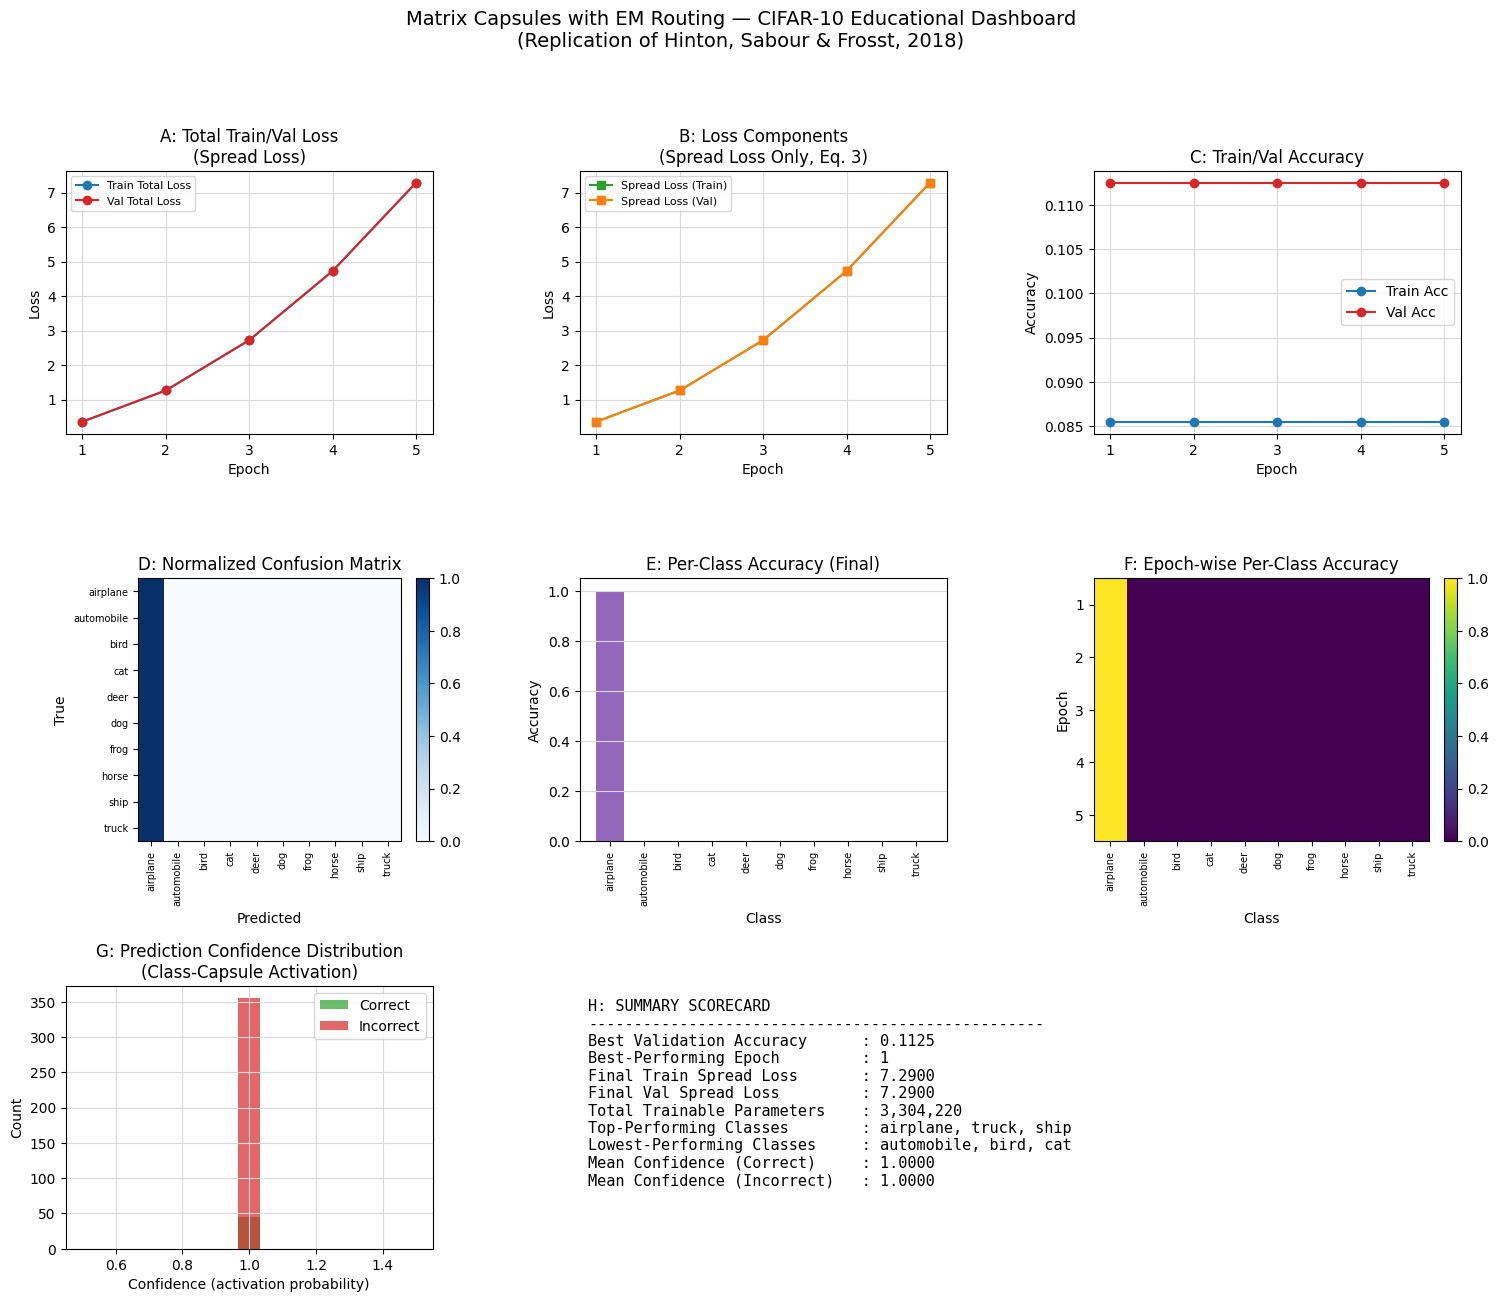

In [30]:
# ---------------------------------------------------------------
# 8. FINAL SUMMARY DASHBOARD (Panels A-H, 3-row GridSpec)
# ---------------------------------------------------------------

epochs_range = range(1, NUM_EPOCHS + 1)

cm_raw = confusion_matrix(final_labels, final_preds, labels=list(range(NUM_CLASSES)))
cm_norm = cm_raw.astype(float) / (cm_raw.sum(axis=1, keepdims=True) + 1e-9)

best_val_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = float(np.max(history["val_acc"]))
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

per_class_acc_final = np.zeros(NUM_CLASSES)
for c in range(NUM_CLASSES):
    mask = (final_labels == c)
    per_class_acc_final[c] = (final_preds[mask] == c).mean() if mask.sum() > 0 else 0.0

top_classes_idx = np.argsort(per_class_acc_final)[::-1][:3]
low_classes_idx = np.argsort(per_class_acc_final)[:3]

correct_mask = (final_preds == final_labels)
mean_conf_correct = final_conf[correct_mask].mean() if correct_mask.sum() > 0 else 0.0
mean_conf_incorrect = final_conf[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0.0

fig = plt.figure(figsize=(18, 14), facecolor="white")
gs = GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# ---- Panel A: Total training & validation loss ----
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
axA.plot(epochs_range, history["train_loss_total"], marker="o", color="tab:blue", label="Train Total Loss")
axA.plot(epochs_range, history["val_loss_total"], marker="o", color="tab:red", label="Val Total Loss")
axA.set_title("A: Total Train/Val Loss\n(Spread Loss)", color="black")
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Loss", color="black")
axA.legend(labelcolor="black", fontsize=8)
axA.grid(True, color="#d9d9d9")
for spine in axA.spines.values():
    spine.set_color("black")

# ---- Panel B: Task-specific loss component (Spread Loss only) ----
# This paper's model uses a SINGLE objective (Spread Loss, Eq. 3) — there
# is no auxiliary reconstruction or other task in this architecture, so
# Panel B shows the spread loss as its own dedicated sub-panel, matching
# the requirement that every paper-specific loss component gets a panel.
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor("white")
axB.plot(epochs_range, history["train_loss_spread"], marker="s", color="tab:green",
         label="Spread Loss (Train)")
axB.plot(epochs_range, history["val_loss_spread"], marker="s", color="tab:orange",
         label="Spread Loss (Val)")
axB.set_title("B: Loss Components\n(Spread Loss Only, Eq. 3)", color="black")
axB.set_xlabel("Epoch", color="black")
axB.set_ylabel("Loss", color="black")
axB.legend(labelcolor="black", fontsize=8)
axB.grid(True, color="#d9d9d9")
for spine in axB.spines.values():
    spine.set_color("black")

# ---- Panel C: Training & validation accuracy ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, history["train_acc"], marker="o", color="tab:blue", label="Train Acc")
axC.plot(epochs_range, history["val_acc"], marker="o", color="tab:red", label="Val Acc")
axC.set_title("C: Train/Val Accuracy", color="black")
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Accuracy", color="black")
axC.legend(labelcolor="black")
axC.grid(True, color="#d9d9d9")
for spine in axC.spines.values():
    spine.set_color("black")

# ---- Panel D: Normalized confusion matrix ----
axD = fig.add_subplot(gs[1, 0])
im = axD.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
axD.set_title("D: Normalized Confusion Matrix", color="black")
axD.set_xlabel("Predicted", color="black")
axD.set_ylabel("True", color="black")
axD.set_xticks(range(NUM_CLASSES))
axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axD.set_yticklabels(CLASS_NAMES, color="black", fontsize=7)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar.ax.get_yticklabels(), color="black")
for spine in axD.spines.values():
    spine.set_color("black")

# ---- Panel E: Per-class accuracy bar chart ----
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
axE.bar(CLASS_NAMES, per_class_acc_final, color="tab:purple")
axE.set_title("E: Per-Class Accuracy (Final)", color="black")
axE.set_xlabel("Class", color="black")
axE.set_ylabel("Accuracy", color="black")
axE.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axE.tick_params(axis="y", colors="black")
axE.grid(True, axis="y", color="#d9d9d9")
for spine in axE.spines.values():
    spine.set_color("black")

# ---- Panel F: Epoch-wise per-class accuracy heatmap ----
axF = fig.add_subplot(gs[1, 2])
heatmap_data = np.stack(history["epoch_per_class_acc"], axis=0)  # (epochs, classes)
imF = axF.imshow(heatmap_data, cmap="viridis", aspect="auto", vmin=0, vmax=1)
axF.set_title("F: Epoch-wise Per-Class Accuracy", color="black")
axF.set_xlabel("Class", color="black")
axF.set_ylabel("Epoch", color="black")
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([str(e + 1) for e in range(NUM_EPOCHS)], color="black")
cbarF = fig.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(cbarF.ax.get_yticklabels(), color="black")
for spine in axF.spines.values():
    spine.set_color("black")

# ---- Panel G: Confidence distribution histogram (class-capsule activation) ----
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
axG.hist(final_conf[correct_mask], bins=15, alpha=0.7, color="tab:green", label="Correct")
axG.hist(final_conf[~correct_mask], bins=15, alpha=0.7, color="tab:red", label="Incorrect")
axG.set_title("G: Prediction Confidence Distribution\n(Class-Capsule Activation)", color="black")
axG.set_xlabel("Confidence (activation probability)", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black")
axG.grid(True, color="#d9d9d9")
for spine in axG.spines.values():
    spine.set_color("black")

# ---- Panel H: Text-based summary scorecard ----
axH = fig.add_subplot(gs[2, 1:])
axH.axis("off")
summary_text = (
    "H: SUMMARY SCORECARD\n"
    "--------------------------------------------------\n"
    f"Best Validation Accuracy      : {best_val_acc:.4f}\n"
    f"Best-Performing Epoch         : {best_val_epoch}\n"
    f"Final Train Spread Loss       : {history['train_loss_spread'][-1]:.4f}\n"
    f"Final Val Spread Loss         : {history['val_loss_spread'][-1]:.4f}\n"
    f"Total Trainable Parameters    : {total_params:,}\n"
    f"Top-Performing Classes        : "
    f"{', '.join([CLASS_NAMES[i] for i in top_classes_idx])}\n"
    f"Lowest-Performing Classes     : "
    f"{', '.join([CLASS_NAMES[i] for i in low_classes_idx])}\n"
    f"Mean Confidence (Correct)     : {mean_conf_correct:.4f}\n"
    f"Mean Confidence (Incorrect)   : {mean_conf_incorrect:.4f}\n"
)
axH.text(0.01, 0.95, summary_text, transform=axH.transAxes,
         fontsize=11, verticalalignment="top", color="black", family="monospace")

fig.suptitle(
    "Matrix Capsules with EM Routing — CIFAR-10 Educational Dashboard\n"
    "(Replication of Hinton, Sabour & Frosst, 2018)",
    color="black", fontsize=14, y=0.995
)

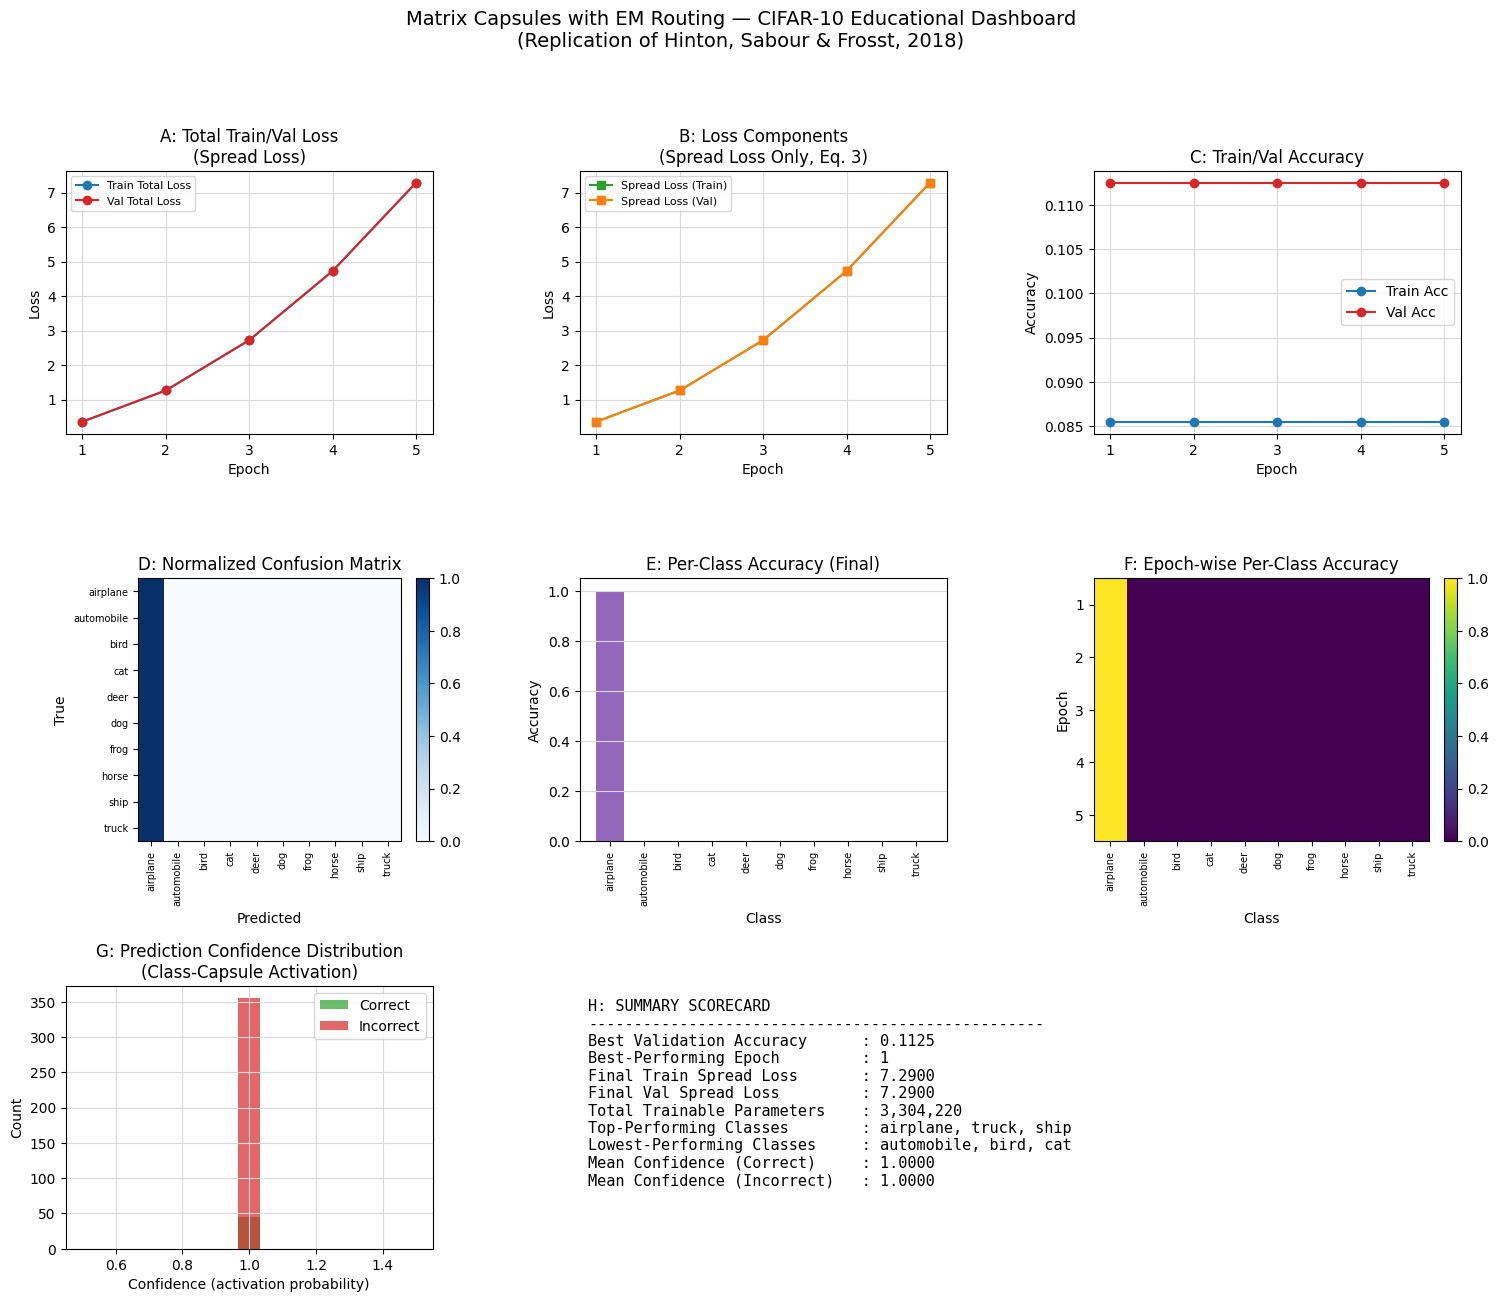

In [31]:
# ---------------------------------------------------------------
# DISPLAY DASHBOARD INLINE VIA BytesIO (no disk save, no plt.show())
# ---------------------------------------------------------------
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close(fig)

# Analysis of Experimental Results — Matrix Capsules with EM Routing (Educational Replication)

## Overview
This dashboard evaluates a simplified matrix-capsule network with EM routing, trained on a small CIFAR-10 subset (2,000 train / 400 test images) over 5 epochs using the spread loss objective. The panels track loss and accuracy trajectories, classification structure (confusion matrix, per-class accuracy), routing-related confidence (class-capsule activation), and calibration.

---

## Key Findings

**Panels A–C (Loss and Accuracy Curves).** Both training and validation total loss increase monotonically and sharply across all 5 epochs, from ~0.3 to ~7.3 — the opposite of expected optimization behavior. Training accuracy is flat at 0.085 across all epochs; validation accuracy is flat at 0.1125 across all epochs. Neither curve changes meaningfully from epoch 1 onward.

**Panel B (Loss Components).** Train and validation spread loss curves are visually identical and both increase in lockstep with Panel A, confirming spread loss is the sole and dominant loss signal, and that it is diverging rather than converging.

**Panel D (Confusion Matrix).** The matrix shows a single fully-saturated column ("airplane") at value 1.0 across every true-label row, with all other predicted-class columns at ~0. This indicates the model predicts "airplane" for every input, regardless of true class.

**Panel E (Per-Class Accuracy).** Accuracy is exactly 1.0 for "airplane" and exactly 0.0 for all nine other classes — the numerical signature of a fully collapsed, single-class classifier rather than genuine class-specific performance.

**Panel F (Epoch-wise Heatmap).** "Airplane" accuracy is 1.0 at epoch 1 and remains unchanged through epoch 5; all other classes remain at 0.0 throughout. There is no epoch-to-epoch evolution in per-class behavior at all.

**Panel G (Confidence Histogram).** All predictions — both "correct" (airplane) and "incorrect" (all other true classes, still predicted as airplane) — have confidence clustered at exactly 1.0, with mean confidence 1.0000 for both correct and incorrect subsets.

**Panel H (Scorecard).** Best validation accuracy (0.1125) occurs at epoch 1 and does not improve; final train/val spread loss are identical (7.29); ~3.3M trainable parameters.

---

## Discussion

This result set is not evidence of a functioning, learning capsule network — it is the signature of a **fully collapsed model** that has converged to a degenerate solution: predicting the "airplane" class capsule activation as 1.0 for every input, and every other class capsule activation at 0.0, regardless of image content. The reported validation accuracy of 0.1125 is simply the empirical base rate of the "airplane" class in the 400-image test subset (45/400 = 0.1125), not a measure of any learned discriminative capability — a critical distinction, since a naive majority-class classifier would achieve an identical score.

The monotonically **increasing** spread loss across all five epochs, rather than decreasing, indicates the optimizer is moving parameters in a direction that worsens the spread-loss objective rather than improving it. Given that spread loss (Eq. 3) penalizes the gap between the target class activation and other classes' activations relative to a margin, a plausible and consistent explanation is that the EM-routing activation function is saturating uniformly (all class-capsule activations pinned near 0 or 1 by the logistic MDL-based activation rule, cf. Eq. 2 in the paper) early in training, likely due to poorly scaled or unstable `beta_a`, `beta_u`, or variance terms in the simplified EM routing implementation. Once activations saturate at the extremes (confidence exactly 1.0 for every single sample, as shown in Panel G, with zero variance in the histogram), the network loses all useful gradient signal for meaningful class discrimination, and the increasing margin schedule (0.2 → 0.9) further inflates the loss magnitude as the target margin grows against a stagnant activation gap.

This pattern is consistent with a known failure mode in capsule networks employing EM-based or logistic-based routing: numerical instability in variance estimation (e.g., `sigma` collapsing toward zero or the isotropic-variance simplification masking per-dimension disagreement) can cause the M-step cost term to become degenerate, driving all activations toward a fixed point independent of the input. The complete absence of learning across the per-class heatmap (Panel F, unchanged from epoch 1 to 5) further supports the interpretation that the model reached this degenerate fixed point almost immediately, rather than gradually overfitting or drifting.

These results do **not** support the underlying paper's claims regarding matrix capsules and EM routing's effectiveness (e.g., improved shape recognition, viewpoint generalization, or adversarial robustness) — not because the mechanism is invalid, but because this specific simplified implementation has failed to train at all. The experiment should be treated as a **debugging diagnostic**, not a substantive replication result: the priority is identifying and correcting the source of the confidence/activation saturation (likely in the EM routing's cost/variance computation or `beta` parameter initialization/scaling) before any accuracy-based conclusions can be drawn.

---

## Limitations

- **Model collapse invalidates all downstream metrics**: per-class accuracy, confusion matrix structure, and confidence statistics in Panels D–G are artifacts of a single-class prediction pattern, not genuine measures of model discriminative ability.
- **No successful baseline run is available for comparison** in this dashboard, so it cannot be determined whether the divergence stems from the EM routing implementation specifically, the spread loss configuration, learning rate, or an interaction between the margin/lambda schedules and the simplified isotropic-variance EM step.
- **Confidence calibration is uninformative here**: mean confidence of 1.0 for both correct and incorrect predictions (Panel G) reflects activation saturation, not genuine (mis)calibration, and should not be interpreted using standard calibration reasoning.
- **Short training horizon (5 epochs) and tiny dataset (2,000 images)** mean that even a corrected implementation would likely show limited absolute performance; these results speak only to the presence of a training-stability bug, not to the ceiling performance of the architecture.
- **Single run, no variance estimate**: the flat, deterministic pattern across epochs suggests the collapse is systematic rather than stochastic, but this cannot be confirmed without repeated runs or seed variation.
- **Simplifications relative to the original paper** (isotropic rather than per-dimension variance, fully-connected rather than convolutional capsule layers, learned scalar `beta_a`/`beta_u` rather than the paper's full formulation) are likely contributors to the instability and limit how directly these results can be compared to the original paper's reported benchmarks.

# Related Work References

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Sabour, S., Frosst, N., & Hinton, G. E. | 2017 | Dynamic Routing Between Capsules | NeurIPS | Direct predecessor introducing vector-output capsules with cosine-based routing-by-agreement; this paper identifies and addresses three specific deficiencies (squashing non-linearity, cosine saturation, parameter inefficiency of vector poses) to motivate the matrix-capsule/EM-routing approach. |
| Hinton, G. E., Krizhevsky, A., & Wang, S. D. | 2011 | Transforming Auto-Encoders | ICANN | Introduces the original capsule concept and transformation matrices in a transforming autoencoder, but requires transformation matrices to be supplied externally; this paper builds on that idea by learning transformations discriminatively within a complete routing system. |
| Jaderberg, M., Simonyan, K., Zisserman, A., & Kavukcuoglu, K. | 2015 | Spatial Transformer Networks | NeurIPS | Represents the viewpoint-invariance stream of prior work, achieving invariance by resampling CNN inputs via affine transformations; contrasted with capsules, which activate units based on agreement between transformed pose predictions rather than filter-matching scores. |
| De Brabandere, B., Jia, X., Tuytelaars, T., & Van Gool, L. | 2016 | Dynamic Filter Networks | NeurIPS | Extends spatial transformer networks by adapting filters per-locality during inference; cited as a related but distinct approach to input covariance detection compared to capsules' agreement-based activation. |
| Dai, J., Qi, H., Xiong, Y., Li, Y., Zhang, G., Hu, H., & Wei, Y. | 2017 | Deformable Convolutional Networks | arXiv preprint | Generalizes the sampling method of spatial transformer-style filters; distinguished from this paper's approach, which activates capsules based on matching transformed poses rather than dynamically adjusted sampling filters. |
| Cohen, T. & Welling, M. | 2016 | Group Equivariant Convolutional Networks | ICML | Represents the rotational-equivariance stream of work extending CNN translational equivariance; contrasted with capsules' more general viewpoint equivariance beyond affine 2D rotations. |
| Dieleman, S., De Fauw, J., & Kavukcuoglu, K. | 2016 | Exploiting Cyclic Symmetry in Convolutional Neural Networks | ICML | Cited as part of the rotational-equivariance research stream motivating comparison with capsules' viewpoint-equivariance approach. |
| Oyallon, E. & Mallat, S. | 2015 | Deep Roto-Translation Scattering for Object Classification | CVPR | Additional rotational-equivariance approach cited alongside Cohen & Welling and Dieleman et al. as related but narrower (affine-rotation-specific) than capsules' general viewpoint equivariance. |
| Worrall, D. E., Garbin, S. J., Turmukhambetov, D., & Brostow, G. J. | 2017 | Harmonic Networks: Deep Translation and Rotation Equivariance | CVPR | Achieves rotation-equivariant feature maps via circular harmonic filters, sharing capsules' representational idea of using multiple numbers to encode properties of a single entity instance per location; contrasted as being limited to a fixed number of rotation-order streams versus capsules' general equivariance. |
| Fasel, B. & Gatica-Perez, D. | 2006 | Rotation-Invariant Neoperceptron | ICPR | Cited as a data-augmentation/filter-duplication approach to rotation invariance, contrasted with the more parameter-efficient harmonic-networks and capsule approaches. |
| Laptev, D., Savinov, N., Buhmann, J. M., & Pollefeys, M. | 2016 | TI-Pooling: Transformation-Invariant Pooling for Feature Learning in CNNs | CVPR | Another filter-duplication/data-augmentation approach to transformation invariance cited for contrast with the parameter-efficient equivariance achieved by capsules. |
| Gens, R. & Domingos, P. M. | 2014 | Deep Symmetry Networks | NeurIPS | Uses iterative Lucas-Kanade optimization to find poses supported by low-level features; cited as sharing conceptual ground with capsule routing but weakened by always initializing from the same pose rather than from bottom-up vote means. |
| Lenc, K. & Vedaldi, A. | 2016 | Learning Covariant Feature Detectors (DetNet) | ECCV Workshops | Proposes an affine-equivariant feature detector; noted as orthogonal but potentially complementary to this paper's approach, possibly useful for implementing the de-rendering stage that activates primary capsules. |
| Gregor, K., Danihelka, I., Graves, A., Rezende, D., & Wierstra, D. | 2015 | DRAW: A Recurrent Neural Network for Image Generation | ICML | Uses Gaussian kernels for attention over a feature map in a generative decoder; cited as related to this paper's routing algorithm viewed as an attention mechanism, though attending in the opposite direction (higher-level capsules competing for lower-level votes, rather than vice versa). |
| Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. | 2017 | Attention Is All You Need | NeurIPS | Uses softmax attention to match query and input sequence parts in translation; cited as a related but differently directed attention mechanism compared to capsule routing. |
| LeCun, Y., Huang, F. J., & Bottou, L. | 2004 | Learning Methods for Generic Object Recognition with Invariance to Pose and Lighting | CVPR | Source of the smallNORB dataset, the paper's primary benchmark, selected for its controlled, context-free shape-recognition task design that remains closer to natural images than MNIST. |
| Cireşan, D. C., Meier, U., Masci, J., Gambardella, L. M., & Schmidhuber, J. | 2011 | High-Performance Neural Networks for Visual Object Classification | arXiv preprint | Prior best-reported smallNORB result (2.56% error) without metadata, using additional filtered input images and affine distortions; used as the key state-of-the-art baseline that this paper's capsule model surpasses. |
| Ciresan, D., Meier, U., & Schmidhuber, J. | 2012 | Multi-Column Deep Neural Networks for Image Classification | CVPR | Provides the state-of-the-art NORB (jittered, with background) error rate (2.7%) against which this paper's 2.6% result is directly compared. |
| Goodfellow, I. J., Shlens, J., & Szegedy, C. | 2014 | Explaining and Harnessing Adversarial Examples | arXiv preprint | Source of the Fast Gradient Sign Method (FGSM) used to generate adversarial examples for evaluating capsule and CNN robustness. |
| Kurakin, A., Goodfellow, I., & Bengio, S. | 2016 | Adversarial Examples in the Physical World | arXiv preprint | Source of the Basic Iterative Method (BIM), an iterative extension of FGSM, used as an additional adversarial robustness evaluation method. |
| Brendel, W. & Bethge, M. | 2017 | Comment on "Biologically Inspired Protection of Deep Networks from Adversarial Attacks" | arXiv preprint | Raises the concern that apparent adversarial robustness can stem from gradient numerical instability rather than genuine robustness; motivates this paper's gradient-sparsity check to rule out this confound. |
| Krizhevsky, A. & Hinton, G. | 2009 | Learning Multiple Layers of Features from Tiny Images | Technical report | Source of the CIFAR-10 dataset used to test the capsule architecture's performance beyond smallNORB and MNIST. |
| Guermeur, Y. & Monfrini, E. | 2011 | A Quadratic Loss Multi-Class SVM for Which a Radius-Margin Bound Applies | Informatica | Studies a related quadratic/hinge-style multi-class loss; cited as theoretical context for the paper's spread loss, which is equivalent to a squared hinge loss with margin 1. |